In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('sl1.csv')

In [4]:
df.head()

,Area,Price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [5]:
df.shape , df.size

((5, 2), 10)

In [6]:
# checking duplicates 
df.duplicated().sum()

np.int64(0)

In [8]:
# checking null values
df.isnull().sum()

Area     0
Price    0
dtype: int64

In [9]:
# checking null values in form of percentage
(df.isnull().sum())/len(df)

Area     0.0
Price    0.0
dtype: float64

In [10]:
# checking outlier always keep in mind that we will not check the outliers in the target column 
# so we are spliting the feature and target form the data
target = df[['Price']]
feature = df[['Area']]

<Axes: >

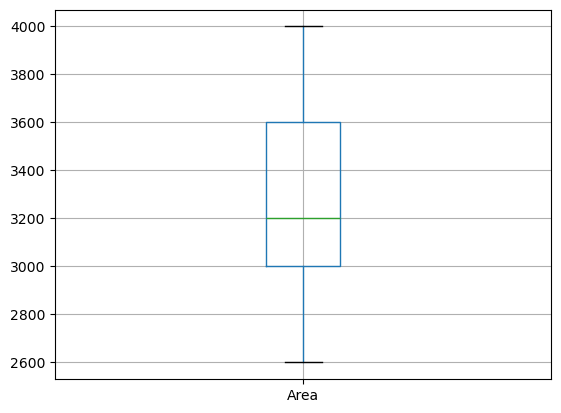

In [11]:
# checking the outliers in the data 
feature.boxplot()

In [12]:
# no outliers in the features 

In [13]:
feature

,Area
0,2600
1,3000
2,3200
3,3600
4,4000


In [14]:
# doing train_test_split
x_train,x_test,y_train,y_test = train_test_split(feature,target,train_size=0.6,random_state=10)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3, 1)
(2, 1)
(3, 1)
(2, 1)


In [15]:
# After the train test split we do scaling in the data 
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()

In [17]:
x_train['Area'] = std_scale.fit_transform(x_train[['Area']])
x_test['Area'] = std_scale.transform(x_test[['Area']])

In [18]:
x_train

,Area
0,-1.019049
4,1.358732
1,-0.339683


In [19]:
x_test

,Area
2,0.000000
3,0.679366


In [20]:
lin_mod = LinearRegression()

In [21]:
# training the model to learn the pattern
lin_mod.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
#doing the prediction with the model 
y_pred = lin_mod.predict(x_train)
y_pred #(Training prediction)

array([[534294.87179487],
       [718717.94871795],
       [586987.17948718]])

In [23]:
y_train.shape , y_pred.shape

((3, 1), (3, 1))

In [24]:
# accuracy during the training
train_acc = r2_score(y_train,y_pred)
print(f"the training accuracy of the model is {train_acc}")

the training accuracy of the model is 0.9591026776589222


In [25]:
# doing prediction for the testing data 
y_pred1 = lin_mod.predict(x_test)
test_acc = r2_score(y_test,y_pred1)
print(f'the testing accuracy of the model is {test_acc}')

the testing accuracy of the model is 0.9157576245488329


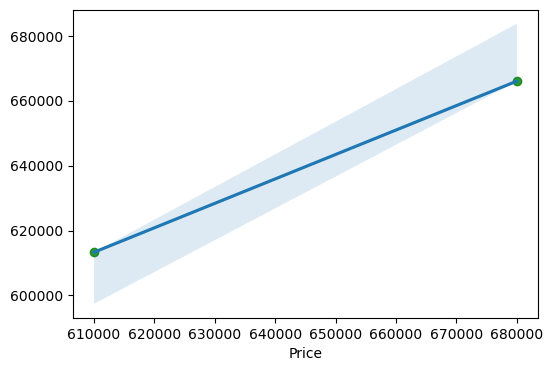

In [26]:
plt.figure(figsize=(6,4))
sns.regplot(x = y_test , y = y_pred1 , scatter_kws={'color':'green'})
plt.show()